In [1]:
import numpy as np
import hmm
import emission_model
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../datasets/sp500_index.csv')

In [3]:

df["Date"] = pd.to_datetime(df["Date"])

In [4]:
df["Date"]

0      2014-12-22
1      2014-12-23
2      2014-12-24
3      2014-12-26
4      2014-12-29
          ...    
2512   2024-12-16
2513   2024-12-17
2514   2024-12-18
2515   2024-12-19
2516   2024-12-20
Name: Date, Length: 2517, dtype: datetime64[ns]

In [5]:
L = df['S&P500'].shape[0]
init_train = 0
final_train = int((5 * L) // 6) - 1

init_test = int((5 * L) // 6) 
final_test = L-1

returns = np.log(df['S&P500'].shift(-1) /  df['S&P500'] )
data_obs = np.array(returns).reshape(1, -1)[:, init_train:final_train+1]

In [6]:
from tqdm import tqdm
### Student's emission
err = []
HMM_list = []
for i in tqdm(range(8)):
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    #emission = emission_model.Discrete_Emission(2, data_obs, 2, B=None)
    student_params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0, 0.05), 20],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05), 20],  # state 1
    #[np.random.uniform(-0.05, 0.05), np.random.uniform(0.0, 0.05), 20]  # state 1
])
    emission = emission_model.Student_Emission(2, data_obs, student_params=student_params)
    HMM = hmm.Hmm(2, 2, emission, pi, A=None)
    err.append(HMM.Baum_Welch_algorithm(data_obs, N_max=35, eps=1e-5))
    HMM_list.append(HMM)
err = np.array(err)

100%|██████████| 8/8 [00:12<00:00,  1.55s/it]


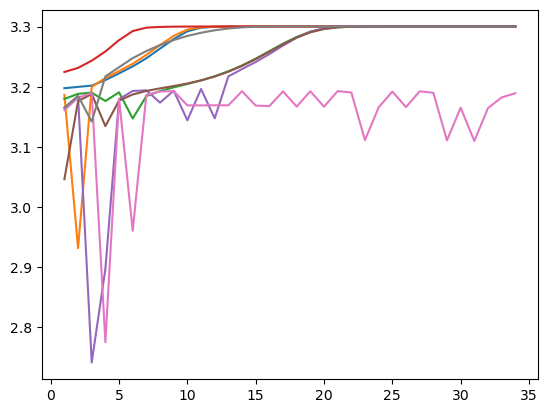

In [7]:
import matplotlib.pyplot as plt

for i in range(8):
    
    plt.plot(range(1, np.array(err).shape[1]-1), np.array(err)[i, 2:])

In [8]:
print(HMM_list[-2].emission.params)

[[ 8.04119649e-04  7.04505414e-03  6.00000000e+02]
 [-2.68828631e-02  1.33129167e-02  6.31710350e+00]]


[[8.09533564e-06 1.31138668e-02 3.94757791e+00]
 [9.73559021e-04 4.69612347e-03 6.51232075e+00]]


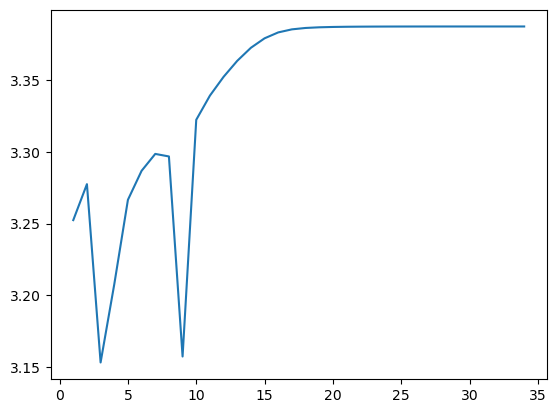

In [8]:
plt.plot(range(1, np.array(err).shape[1]-1), np.array(err)[1, 2:])
print(HMM_list[1].emission.params)
par = HMM_list[1].emission.params

In [9]:
data_obs = np.array([[1], [1]])
student_params = np.array([0, 1, 1]*2)
student_em = emission_model.Student_Emission(2, data_obs)
x = np.linspace(-0.25, 0.25, 1000)

y = student_em.Student(x, par[0, 0], par[0, 1], par[0, 2])

y2 = student_em.Student(x, par[1, 0], par[1, 1], par[1, 2])
y3 = student_em.Student(x, par[2, 0], par[2, 1], par[2, 2])
plt.plot(x, y)
plt.plot(x, y2)
plt.plot(x, y3)

IndexError: index 2 is out of bounds for axis 0 with size 2

In [ ]:
err = []
HMM_list = []
for i in range(15):
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    #emission = emission_model.Discrete_Emission(2, data_obs, 2, B=None)
    gauss_params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(-0.01, 0.01)],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(-0.01, 0.01)],  # state 1, 
    
])
    emission = emission_model.Gaussian_Emission(2, data_obs, gauss_params=gauss_params)
    HMM = hmm.Hmm(2, 2, emission, pi, A=None)
    err.append(HMM.Baum_Welch_algorithm(data_obs, N_max=35, eps=1e-8))
    HMM_list.append(HMM)
err = np.array(err)

/home/lorenzo-lanzini/Desktop/quant-research/HMM_regime_detection/hmm.py:117: RuntimeWarning: invalid value encountered in divide
  A_prime = gamma_ij[:, :-1, :, :].sum(axis=(0, 1)) / (((gamma[:, :-1, :]/(c[:, :-1, np.newaxis])).sum(axis=(0,1)))[:, np.newaxis])
/home/lorenzo-lanzini/Desktop/quant-research/HMM_regime_detection/emission_model.py:88: RuntimeWarning: invalid value encountered in divide
  self.gauss_params[:, 0] = (gamma[:, :, :] * self.data_obs[:, :, np.newaxis]/c[:, :, np.newaxis]).sum(axis=(0,1)) / (gamma[:, :, :]/c[:, :, np.newaxis]).sum(axis=(0,1))
/home/lorenzo-lanzini/Desktop/quant-research/HMM_regime_detection/emission_model.py:89: RuntimeWarning: invalid value encountered in divide
  self.gauss_params[:, 1] = np.sqrt((gamma[:, :, :] * self.data_obs[:, :, np.newaxis]**2 /c[:, :, np.newaxis]).sum(axis=(0,1)) / (gamma[:, :, :]/c[:, :, np.newaxis]).sum(axis=(0,1)) - self.gauss_params[:, 0]**2)
/home/lorenzo-lanzini/Desktop/quant-research/HMM_regime_detection/hmm.py:121

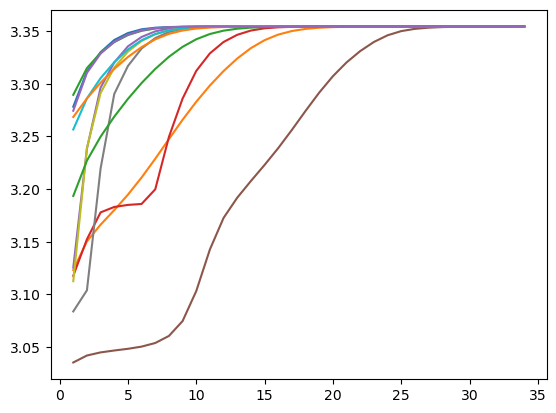

In [ ]:
import matplotlib.pyplot as plt

for i in range(15):
    
    plt.plot(range(1, np.array(err).shape[1]-1), np.array(err)[i, 2:])

In [ ]:
print(HMM_list[-1].emission.gauss_params)

if HMM_list[-1].emission.gauss_params[0, 0] <0:
    colors = ['red', 'green']

else:
    colors=colors = ['green', 'red']

[[-0.00143517  0.02104588]
 [ 0.00104738  0.0057999 ]]


In [ ]:
HMM.emission.gauss_params

AttributeError: 'Student_Emission' object has no attribute 'gauss_params'

In [10]:
HMM=HMM_list[1]
HMM.Viterbi(data_obs)

In [11]:
print(HMM.best_seqs.shape)

(1, 2097)


In [12]:
import matplotlib.pyplot as plt
import numpy as np

def plot_regimes(dates,prices, hidden_states, n_states):
    
    
    colors = ['red', 'green']
    
    
    fig, ax = plt.subplots(figsize=(14, 5))
    
    ax.plot(dates, prices, color='black', linewidth=2, zorder=2)
    
    # colora le regioni
    i = 0
    while i < len(hidden_states):
        state = int(hidden_states[i])
        j = i
        # trova fino a dove dura questo regime
        while j < len(hidden_states) and hidden_states[j] == state:
            j += 1
        ax.axvspan(dates[i], dates[min(j, len(dates)-1)], 
                   alpha=0.3, color=colors[state], zorder=1)
        i = j
    
    # legenda manuale
    from matplotlib.patches import Patch
    legend = [Patch(facecolor=colors[k], alpha=0.3, label=f'Regime {k}') 
              for k in range(n_states)]
    ax.legend(handles=legend, loc='upper left')
    
    ax.set_xlabel('time')
    ax.set_ylabel('return')
    plt.tight_layout()
    plt.show()

In [13]:
df['S&P500'].shape
HMM.best_seqs[0, :].shape

(2097,)

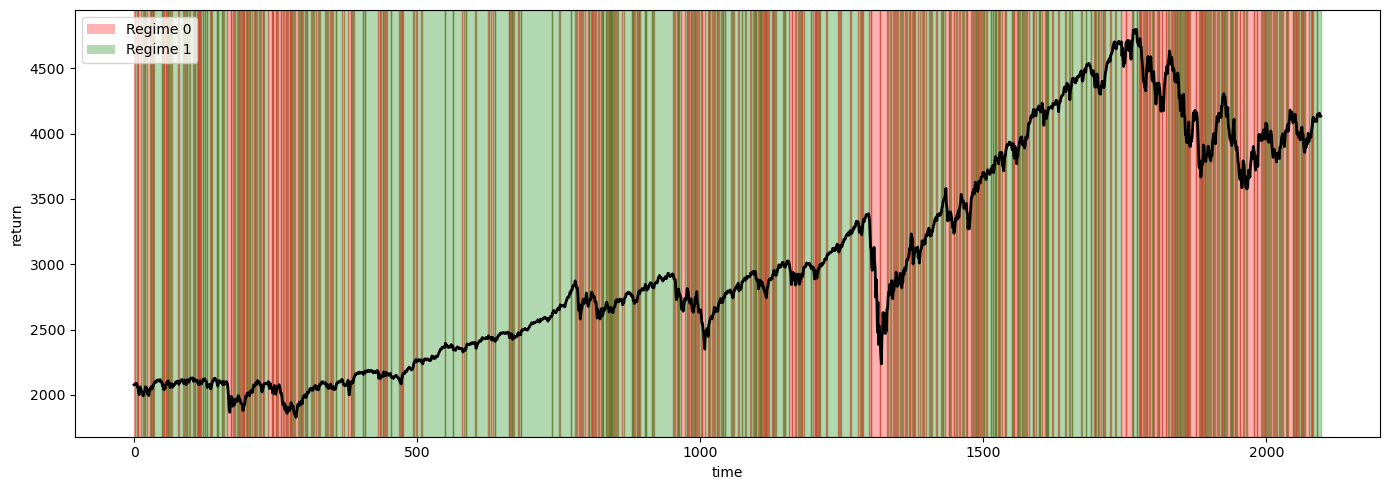

In [14]:
dates = [i for i in range(final_train - init_train +1)]

plot_regimes(dates[:], np.array(df['S&P500'])[init_train:final_train+1], HMM.best_seqs[0, :] , n_states=2)

In [16]:
data_obs_test=np.array(returns).reshape(1, -1)[:, init_test:final_test]
HMM.Viterbi(data_obs_test)

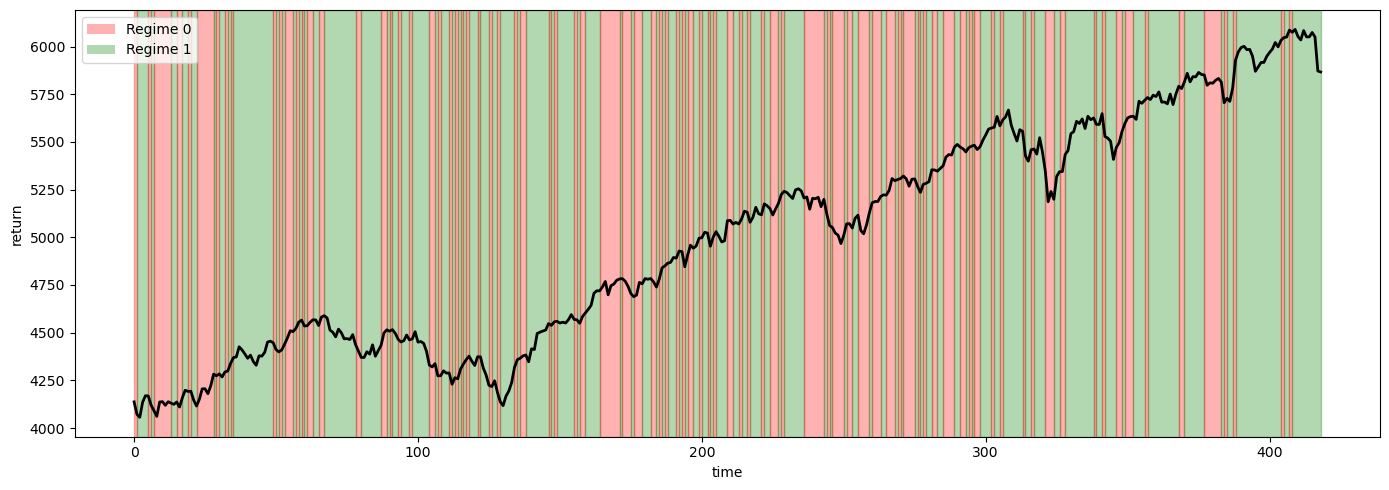

In [17]:
dates = [i for i in range(final_test-init_test)]

plot_regimes(dates[:], np.array(df['S&P500'])[init_test:final_test], HMM.best_seqs[0, :] , n_states=2)

In [ ]:
test_likelihood = HMM.compute_likelihood(data_obs_test)

In [ ]:
test_likelihood

array([3.5076636])

In [ ]:
### Student's emission
err = []
HMM_list = []
for i in range(15):
    pi = np.random.rand((2))
    pi = pi/np.sum(pi)
    #emission = emission_model.Discrete_Emission(2, data_obs, 2, B=None)
    student_params = np.array([
    [np.random.uniform(-0.05, 0.05), np.random.uniform(-0.01, 0.01), 6],  # state 0
    [np.random.uniform(-0.05, 0.05), np.random.uniform(-0.01, 0.01), 6],  # state 1
])
    emission = emission_model.Student_Emission(2, data_obs, student_params=student_params)
    HMM = hmm.Hmm(2, 2, emission, pi, A=None)
    err.append(HMM.Baum_Welch_algorithm(data_obs, N_max=35, eps=1e-8))
    HMM_list.append(HMM)
err = np.array(err)

ValueError: f(a) and f(b) must have different signs